### Classificação

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt
import re

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Airbnb_NYC_2019_VF.csv")

##### Criação do indicador de sucesso

In [2]:
def define_success(availability):
    q25 = availability.quantile(0.25)
    q75 = availability.quantile(0.75)
    if q25 == 0:
        q25 = availability[availability > 0].min()
    bins = [0, q25, q75, 365]
    labels = ['low', 'medium', 'high']
    return pd.cut(availability, bins=bins, labels=labels)

df["success"] = define_success(df["availability_365"])
df.dropna(subset=["success"], inplace=True)

le = LabelEncoder()
df["success"] = le.fit_transform(df["success"])
classes = le.classes_

### Teste de vários cenários com Árvores de Decisão e Redes Neuronais

In [3]:
df['interaction1'] = df['neighbourhood_group'] * df['number_of_reviews']
df['interaction2'] = df['neighbourhood_group'] * df['attractions']
df['interaction3'] = df['neighbourhood'] * df['minimum_nights']
df['interaction4'] = df['neighbourhood'] * df['attractions']

scenarios = [
    ("Scenario 1", ['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood_group', 'price']),
    ("Scenario 2", ['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood_group', 'price', 'minimum_nights']),
    ("Scenario 3", ['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood_group', 'price', 'number_of_reviews', 'attractions']),
    ("Scenario 4", ['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood', 'price']),
    ("Scenario 5", ['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood_group', 'price', 'number_of_reviews', 'attractions', 'interaction2']),
    ("Scenario 6", ['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood_group', 'price', 'number_of_reviews', 'attractions', 'interaction1', 'interaction2']),
    ("Scenario 7", ['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood', 'price', 'number_of_reviews', 'attractions']),
    ("Scenario 8", ['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood', 'price', 'minimum_nights']),
    ("Scenario 9", ['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood', 'price', 'number_of_reviews', 'attractions', 'interaction4']),
    ("Scenario 10", ['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood', 'price', 'minimum_nights', 'interaction3'])
]

##### 70% treino e 30% teste

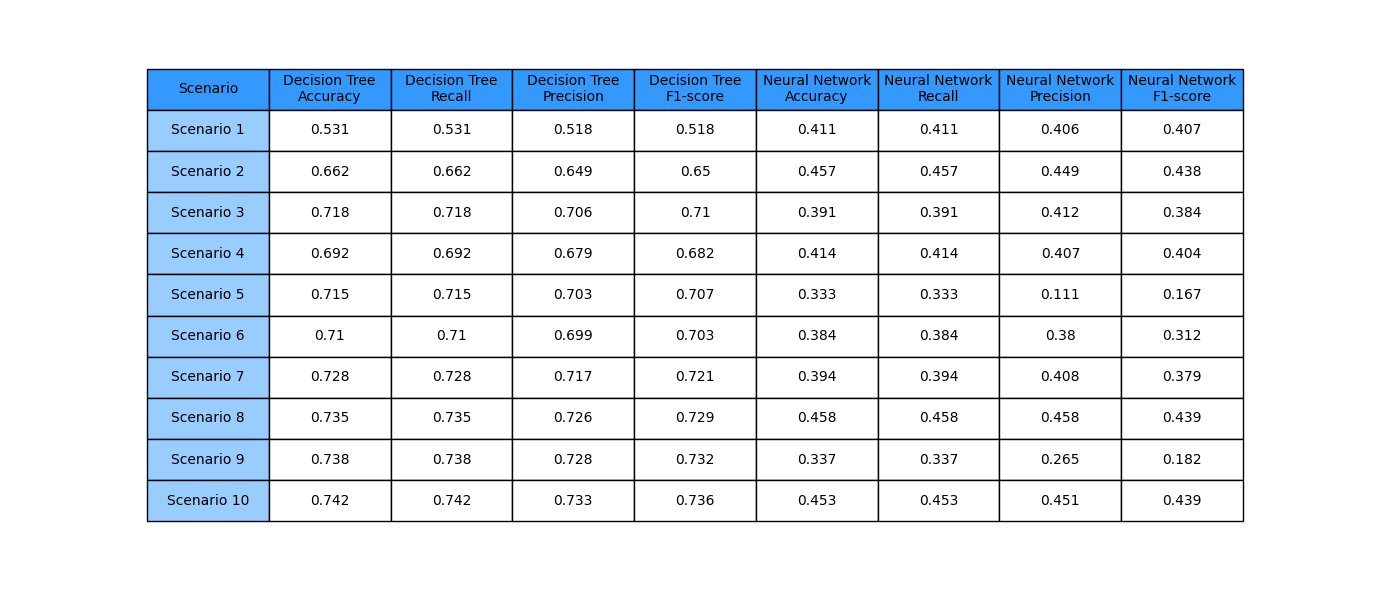

In [ ]:
accuracies = []
data_table = []

saved_results = {}

for name_scenario, features in scenarios:
    X = df[features].copy()
    y = df["success"]
    
    df_scenario = X.copy()
    df_scenario["success"] = y

    dfs = []
    for label in df_scenario["success"].unique():
        temp = df_scenario[df_scenario["success"] == label]
        dfs.append(resample(temp, replace=True, n_samples=5000, random_state=42))
        
    df_bal = pd.concat(dfs)

    X_bal = df_bal.drop(columns=["success"])
    y_bal = df_bal["success"]

    Xtr, Xts, ytr, yts = train_test_split(X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal)

    # ----- Decision Tree -----
    dt = DecisionTreeClassifier(max_depth=40, random_state=42)
    dt.fit(Xtr, ytr)
    pred_dt = dt.predict(Xts)
    acc_dt = accuracy_score(yts, pred_dt)
    recall_dt = recall_score(yts, pred_dt, average='macro')
    precision_dt = precision_score(yts, pred_dt, average='macro')
    f1_dt = f1_score(yts, pred_dt, average='macro')

    # ----- Neural Network -----
    nn = MLPClassifier(hidden_layer_sizes=(10, 5, 2), max_iter=900, random_state=42)
    nn.fit(Xtr, ytr)
    pred_nn = nn.predict(Xts)
    acc_nn = accuracy_score(yts, pred_nn)
    recall_nn = recall_score(yts, pred_nn, average='macro')
    precision_nn = precision_score(yts, pred_nn, average='macro')
    f1_nn = f1_score(yts, pred_nn, average='macro')

    accuracies.append([
        name_scenario,
        acc_dt,
        acc_nn
    ])

    data_table.append([
        name_scenario,
        round(acc_dt, 3), round(recall_dt, 3), round(precision_dt, 3), round(f1_dt, 3),
        round(acc_nn, 3), round(recall_nn, 3), round(precision_nn, 3), round(f1_nn, 3)
    ])
    
    saved_results[name_scenario] = {
        'yts': yts,
        'dt_probs': dt.predict_proba(Xts),
        'nn_probs': nn.predict_proba(Xts),
        'dt_model': dt,
        'nn_model': nn,
        'Xts': Xts
    }

colummns_accuracies = pd.MultiIndex.from_tuples([
    ("Scenario", ""),
    ("Decision Tree", "Accuracy"),
    ("Neural Network", "Accuracy")
])
df_accuracies = pd.DataFrame(accuracies, columns=colummns_accuracies)

columns = pd.MultiIndex.from_tuples([
    ("Scenario", ""),
    ("Decision Tree", "Accuracy"),
    ("Decision Tree", "Recall"),
    ("Decision Tree", "Precision"),
    ("Decision Tree", "F1-score"),
    ("Neural Network", "Accuracy"),
    ("Neural Network", "Recall"),
    ("Neural Network", "Precision"),
    ("Neural Network", "F1-score")
])
df_results = pd.DataFrame(data_table, columns=columns)

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

table = ax.table(cellText=df_results.values,
                 colLabels=[f"{a}\n{b}" if b else a for a, b in df_results.columns],
                 loc='center',
                 cellLoc='center',
                 colLoc='center',
                 colColours=["#3399FF"] * len(df_results.columns))

table.scale(0.8, 2)
table.auto_set_font_size(False)
table.set_fontsize(10)

for row in range(1, len(df_results) + 1):
    table[row, 0].set_facecolor("#99CCFF")

plt.tight_layout()
plt.show()

##### 10-fold cross-validation

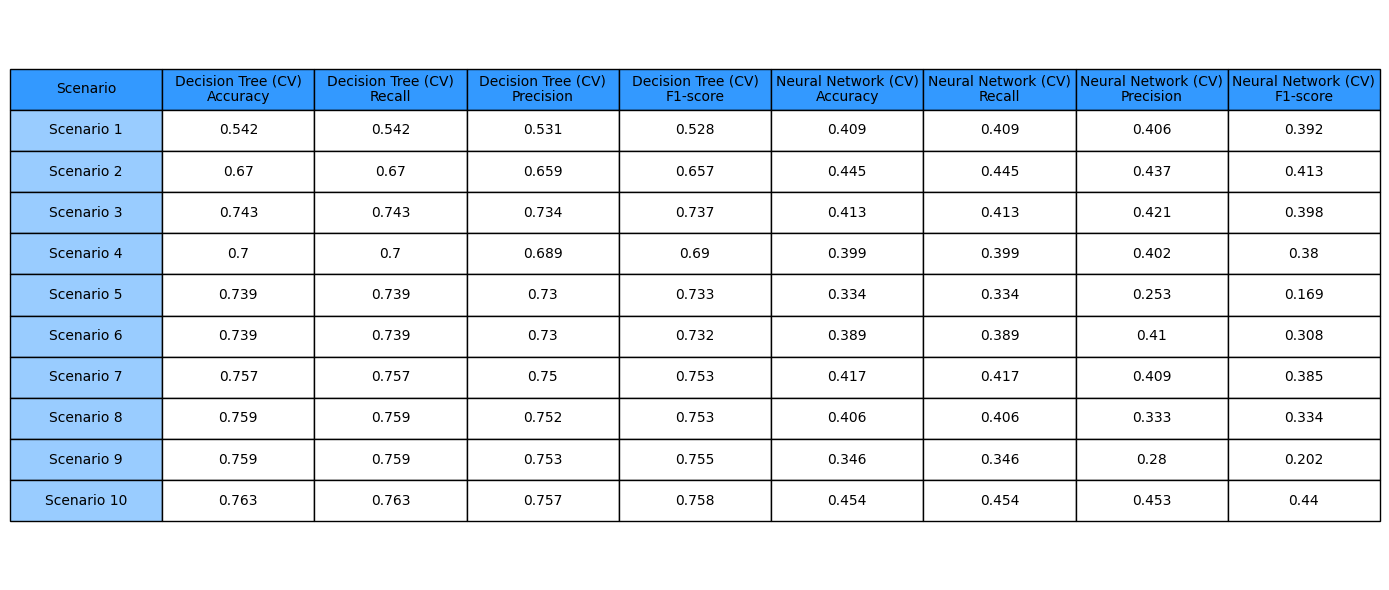

In [5]:
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

accuracies_kfold = []
data_table_kfold = []

saved_results_kfold = {}

for name_scenario, features in scenarios:
    X = df[features].copy()
    y = df["success"]

    df_scenario = X.copy()
    df_scenario["success"] = y

    dfs = []
    for label in df_scenario["success"].unique():
        temp = df_scenario[df_scenario["success"] == label]
        dfs.append(resample(temp, replace=True, n_samples=5000, random_state=42))
    df_bal = pd.concat(dfs)

    X_bal = df_bal.drop(columns=["success"]).values
    y_bal = df_bal["success"].values

    dt_metrics = {'acc': [], 'recall': [], 'prec': [], 'f1': []}
    nn_metrics = {'acc': [], 'recall': [], 'prec': [], 'f1': []}
    
    all_yts = []
    all_dt_probs = []
    all_nn_probs = []
    all_Xts = []
    all_prev_dt = []
    all_prev_nn = []

    for train_idx, test_idx in kf.split(X_bal, y_bal):
        Xtr, Xts = X_bal[train_idx], X_bal[test_idx]
        ytr, yts = y_bal[train_idx], y_bal[test_idx]

        # ----- Decision Tree -----
        dt = DecisionTreeClassifier(max_depth=40, random_state=42)
        dt.fit(Xtr, ytr)
        pred_dt = dt.predict(Xts)
        dt_metrics['acc'].append(accuracy_score(yts, pred_dt))
        dt_metrics['recall'].append(recall_score(yts, pred_dt, average='macro'))
        dt_metrics['prec'].append(precision_score(yts, pred_dt, average='macro'))
        dt_metrics['f1'].append(f1_score(yts, pred_dt, average='macro'))

        # ----- Neural Network -----
        nn = MLPClassifier(hidden_layer_sizes=(10, 5, 2), max_iter=900, random_state=42)
        nn.fit(Xtr, ytr)
        pred_nn = nn.predict(Xts)
        nn_metrics['acc'].append(accuracy_score(yts, pred_nn))
        nn_metrics['recall'].append(recall_score(yts, pred_nn, average='macro'))
        nn_metrics['prec'].append(precision_score(yts, pred_nn, average='macro'))
        nn_metrics['f1'].append(f1_score(yts, pred_nn, average='macro'))
        
        all_yts.extend(yts)
        all_dt_probs.extend(dt.predict_proba(Xts))
        all_nn_probs.extend(nn.predict_proba(Xts))
        all_Xts.append(Xts)
        all_prev_dt.extend(pred_dt)
        all_prev_nn.extend(pred_nn)

    accuracies_kfold.append([
        name_scenario,
        float(np.mean(dt_metrics['acc'])),
        float(np.mean(nn_metrics['acc']))
    ])

    data_table_kfold.append([
        name_scenario,
        round(np.mean(dt_metrics['acc']), 3),
        round(np.mean(dt_metrics['recall']), 3),
        round(np.mean(dt_metrics['prec']), 3),
        round(np.mean(dt_metrics['f1']), 3),
        round(np.mean(nn_metrics['acc']), 3),
        round(np.mean(nn_metrics['recall']), 3),
        round(np.mean(nn_metrics['prec']), 3),
        round(np.mean(nn_metrics['f1']), 3),
    ])
    
    saved_results_kfold[name_scenario] = {
        'yts': np.array(all_yts),
        'dt_probs': np.array(all_dt_probs),
        'nn_probs': np.array(all_nn_probs),
        'Xts': np.vstack(all_Xts),
        'prev_dt': np.array(all_prev_dt),
        'prev_nn': np.array(all_prev_nn)
    }

colummns_accuracies_kfold = pd.MultiIndex.from_tuples([
    ("Scenario", ""),
    ("Decision Tree (CV)", "Accuracy"),
    ("Neural Network (CV)", "Accuracy")
])
df_accuracies_kfold = pd.DataFrame(accuracies_kfold, columns=colummns_accuracies_kfold)

columns_kfold = pd.MultiIndex.from_tuples([
    ("Scenario", ""),
    ("Decision Tree (CV)", "Accuracy"),
    ("Decision Tree (CV)", "Recall"),
    ("Decision Tree (CV)", "Precision"),
    ("Decision Tree (CV)", "F1-score"),
    ("Neural Network (CV)", "Accuracy"),
    ("Neural Network (CV)", "Recall"),
    ("Neural Network (CV)", "Precision"),
    ("Neural Network (CV)", "F1-score")
])
df_kfold_results = pd.DataFrame(data_table_kfold, columns=columns_kfold)

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

table = ax.table(cellText=df_kfold_results.values,
                 colLabels=[f"{a}\n{b}" if b else a for a, b in df_kfold_results.columns],
                 loc='center',
                 cellLoc='center',
                 colLoc='center',
                 colColours=["#3399FF"] * len(df_kfold_results.columns))

table.scale(1, 2)
table.auto_set_font_size(False)
table.set_fontsize(10)

for row in range(1, len(df_kfold_results) + 1):
    table[row, 0].set_facecolor("#99CCFF")

plt.tight_layout()
plt.show()

##### melhores cenários

In [6]:
df_split = df_accuracies.copy()
df_kfold = df_accuracies_kfold.copy()

def stack_all_results(df_split, df_kfold):
    results = []

    for df, suffix in [(df_split, ""), (df_kfold, " (CV)")]:
        for model in ["Decision Tree", "Neural Network"]:
            col_name = (model + suffix, "Accuracy")
            if col_name in df.columns:
                for _, row in df.iterrows():
                    scenario_raw = row[("Scenario", "")]
                    match = re.search(r"\d+", str(scenario_raw))
                    if not match:
                        continue
                    scenario_num = int(match.group())
                    results.append({
                        "Scenario": scenario_num,
                        "Model": model,
                        "Accuracy": row[col_name],
                        "Suffix": suffix,
                        "Source": "kfold" if suffix else "split"
                    })

    return pd.DataFrame(results)

all_results = stack_all_results(df_split, df_kfold)

top2 = all_results.sort_values("Accuracy", ascending=False).head(2)

print("Best scenarios:")

best = {}

for i, row in top2.iterrows():
    scenario_num = row["Scenario"]
    scenario_str = f"Scenario {scenario_num} - {row['Model']}{row['Suffix']}"
    print(scenario_str)

    df = df_kfold if row["Suffix"] == " (CV)" else df_split
    match_row = df[df[("Scenario", "")] == f"Scenario {scenario_num}"].iloc[0]
    best[scenario_num] = {
        "row": match_row,
        "model": row["Model"],
        "suffix": row["Suffix"]
    }

Best scenarios:
Scenario 10 - Decision Tree (CV)
Scenario 9 - Decision Tree (CV)


### Matriz de confusão

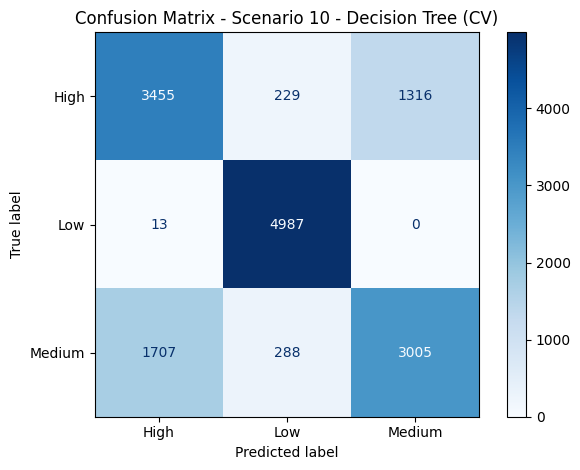

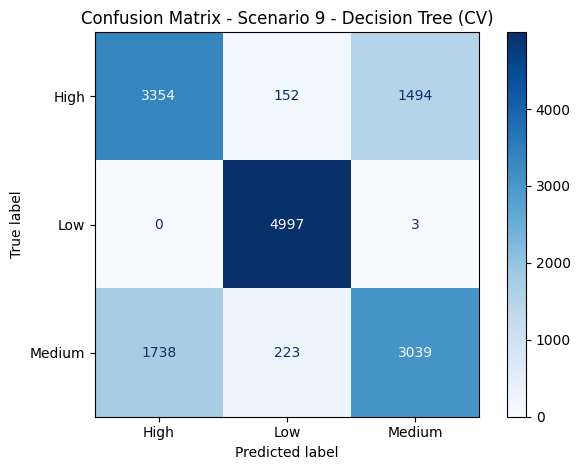

In [7]:
# ----- Confusion Matrix -----
def plot_confusion_matrix(y_test, y_pred, labels, labels_names, title):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title(title)
    plt.tight_layout()
    plt.show()

labels = [0, 1, 2]
labels_names = ["High", "Low", "Medium"]

plot = set()

for scenario, data in best.items():
    if scenario in plot:
        continue

    plot.add(scenario)

    best_row = data["row"]
    model_name = data["model"]
    suffix = data["suffix"]

    key = f"Scenario {scenario}"
    match = df_kfold[df_kfold[("Scenario", "")] == key]
    if not match.empty and best_row.equals(match.iloc[0]):
        is_cv = True
        result_dict = saved_results_kfold.get(key)
        suffix = " (CV)"
    else:
        is_cv = False
        result_dict = saved_results.get(key)
        suffix = ""

    X_test = result_dict["Xts"]
    y_test = result_dict["yts"]

    if is_cv:
        y_pred = result_dict["prev_dt"] if model_name == "Decision Tree" else result_dict["prev_nn"]
    else:
        model = result_dict["dt_model"] if model_name == "Decision Tree" else result_dict["nn_model"]
        y_pred = model.predict(X_test)

    title = f"Confusion Matrix - {key} - {model_name}{suffix}"
    plot_confusion_matrix(y_test, y_pred, labels, labels_names, title)

### Curvas ROC

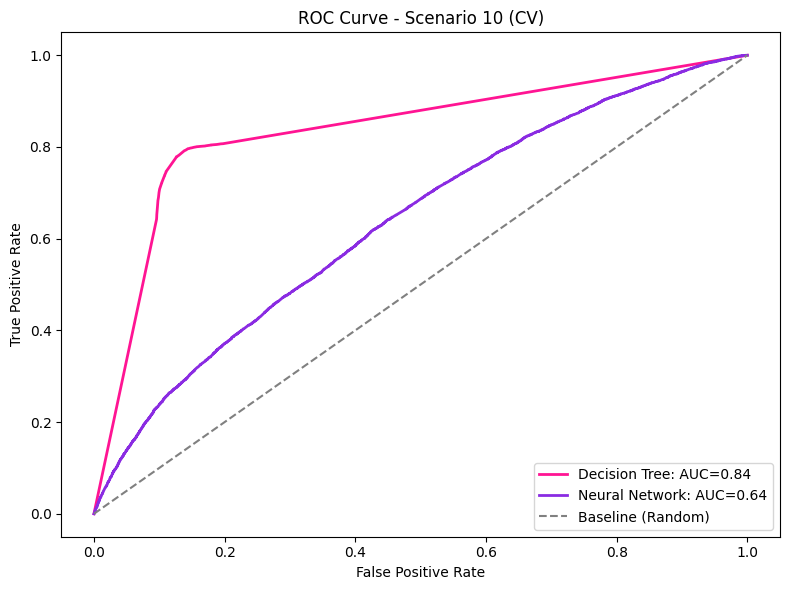

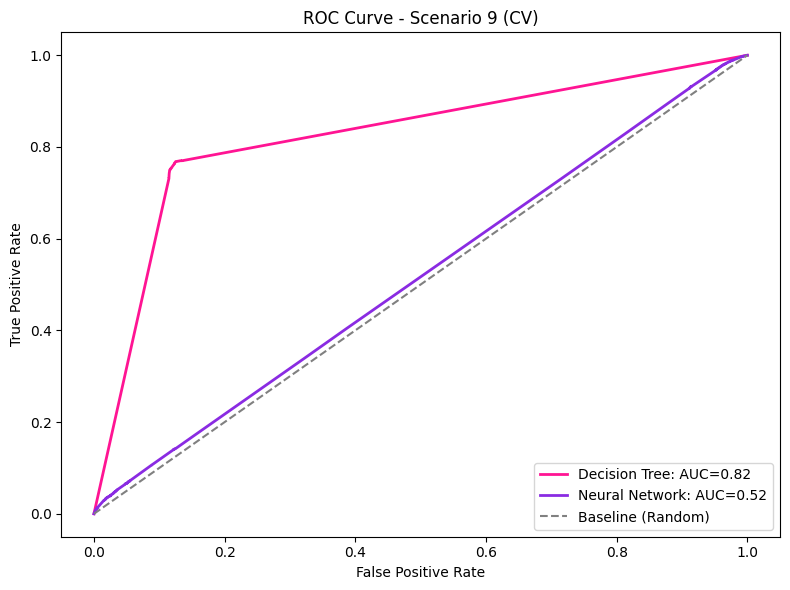

In [ ]:
# ----- ROC Curve -----
colors = {
    'Decision Tree': "#FF1493",
    'Neural Network': '#8A2BE2'
}

plot = set()

for scenario, data in best.items():
    best_row = data["row"]
    suffix = data["suffix"]

    if scenario in plot:
        continue

    plot.add(scenario)

    key = f"Scenario {scenario}"
    match = df_kfold[df_kfold[("Scenario", "")] == key]
    if not match.empty and best_row.equals(match.iloc[0]):
        result_dict = saved_results_kfold.get(key)
        suffix = " (CV)"
    else:
        result_dict = saved_results.get(key)
        suffix = ""

    yts = result_dict["yts"]
    y_bin = label_binarize(yts, classes=np.unique(yts))

    plt.figure(figsize=(8, 6))

    for model_name, probs_key in [
        ("Decision Tree", "dt_probs"),
        ("Neural Network", "nn_probs")
    ]:
        probs = result_dict[probs_key]
        if probs.shape != y_bin.shape:
            print(f"Warning: Probability shape mismatch in {model_name} for {key}")
            continue

        fpr, tpr, _ = roc_curve(y_bin.ravel(), probs.ravel())
        roc_auc_val = auc(fpr, tpr)

        plt.plot(
            fpr, tpr,
            label=f'{model_name}: AUC={roc_auc_val:.2f}',
            color=colors[model_name],
            linewidth=2
        )

    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Baseline (Random)')
    plt.title(f"ROC Curve - Scenario {scenario}{suffix}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

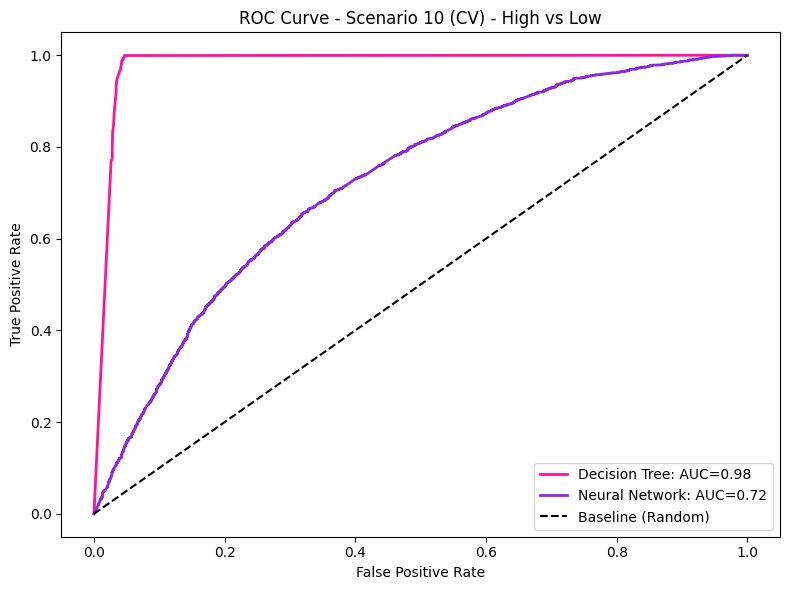

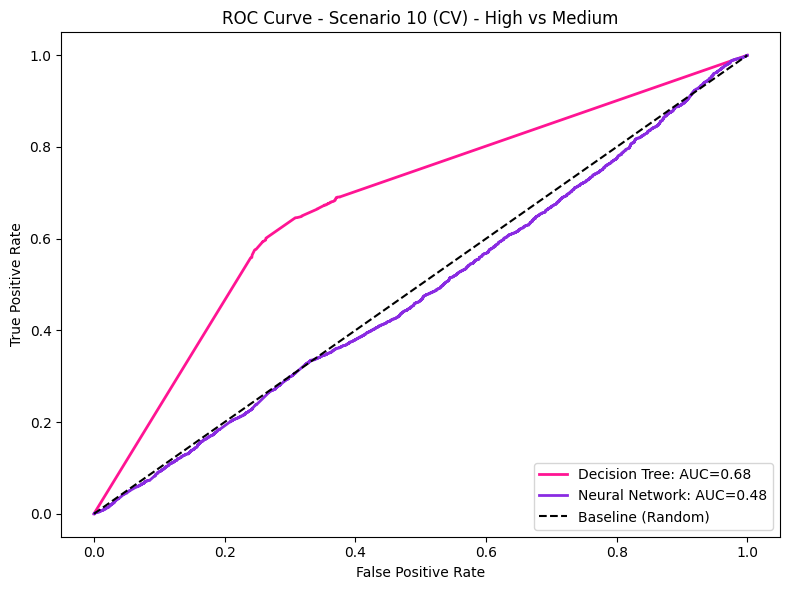

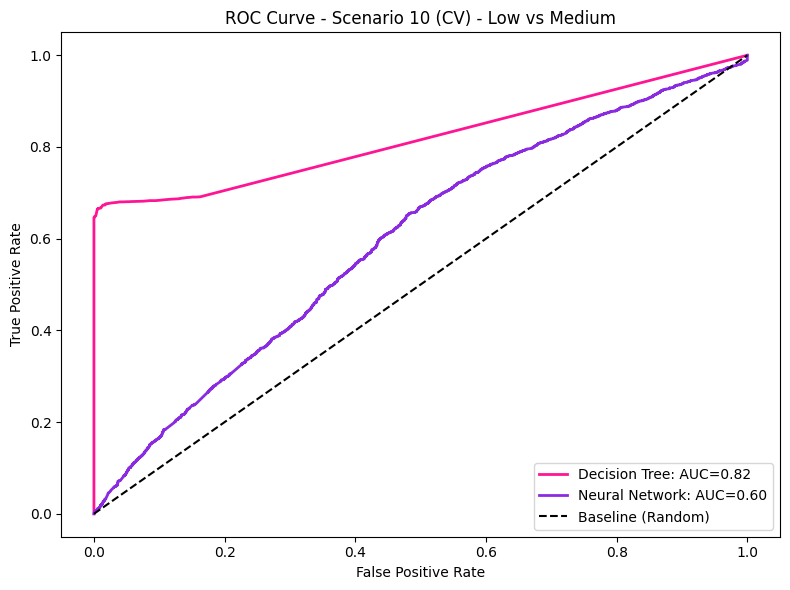

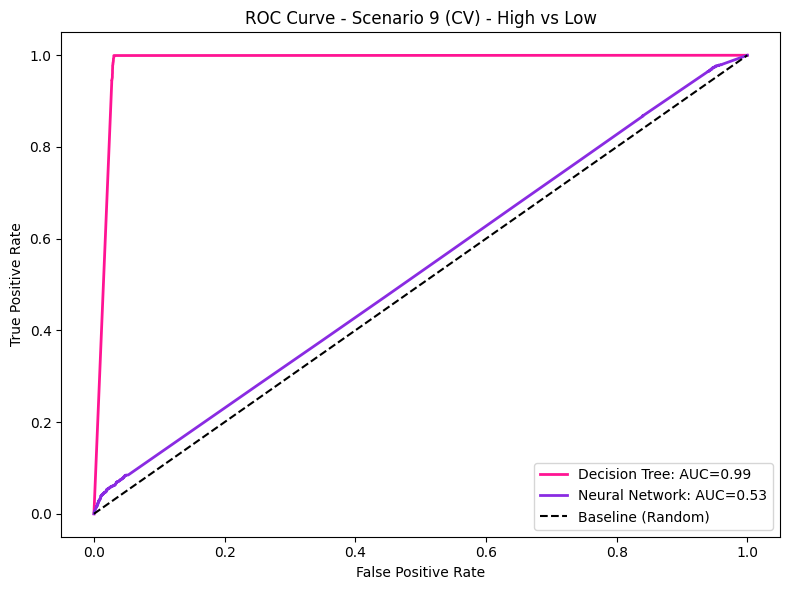

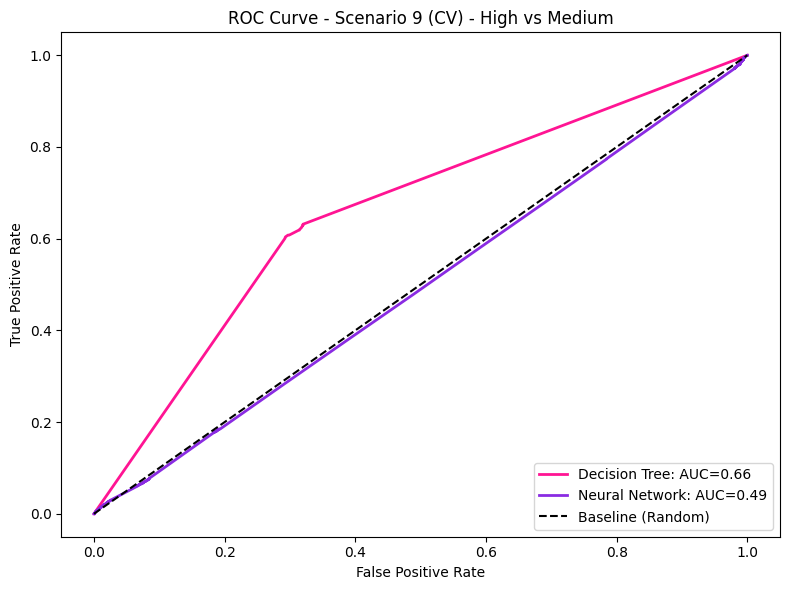

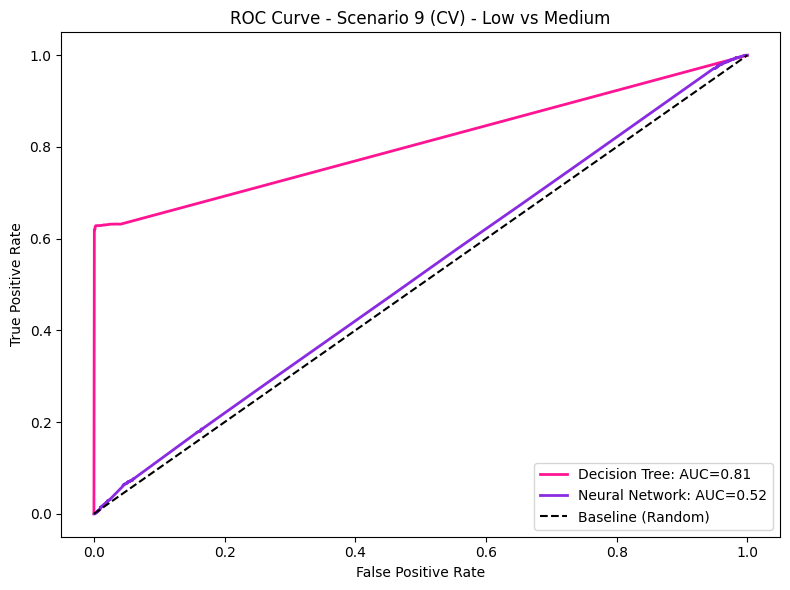

In [9]:
# ----- ROC Curve -----
colors = {
    'Decision Tree': "#FF1493",
    'Neural Network': '#8A2BE2'
}

class_pairs = [(0, 1), (0, 2), (1, 2)]
class_names = {0: "High", 1: "Low", 2: "Medium"}

plot = set()

for scenario, data in best.items():
    best_row = data["row"]
    suffix = data["suffix"]

    if scenario in plot:
        continue

    plot.add(scenario)

    key = f"Scenario {scenario}"
    match = df_kfold[df_kfold[("Scenario", "")] == key]
    if not match.empty and best_row.equals(match.iloc[0]):
        result_dict = saved_results_kfold.get(key)
        suffix = " (CV)"
    else:
        result_dict = saved_results.get(key)
        suffix = ""

    yts = result_dict["yts"]

    for class_a, class_b in class_pairs:
        mask = np.isin(yts, [class_a, class_b])
        y_filtered = yts[mask]

        plt.figure(figsize=(8, 6))

        for model_name, probs_key in [("Decision Tree", "dt_probs"), ("Neural Network", "nn_probs")]:
            probs = result_dict[probs_key][mask]

            y_binary = (y_filtered == class_b).astype(int)

            class_index = class_b
            probs_binary = probs[:, class_index]

            fpr, tpr, _ = roc_curve(y_binary, probs_binary)
            roc_auc_val = auc(fpr, tpr)

            plt.plot(
                fpr, tpr,
                label=f'{model_name}: AUC={roc_auc_val:.2f}',
                color=colors[model_name],
                linewidth=2
            )

        title = f"ROC Curve - Scenario {scenario}{suffix} - {class_names[class_a]} vs {class_names[class_b]}"
        plt.plot([0, 1], [0, 1], 'k--', label='Baseline (Random)')
        plt.title(title)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()